# 02 — Regime detection: what kind of market are we in?

**Tool:** `quantroll.RollingRegimes` (+ `select_n_regimes`) · **Data:** SPY daily returns, 2012 → today.

## The big picture

Notebook 01 introduced the theme of this series: rolling estimates only become useful — monitorable, wireable, auditable — when consecutive answers share an identity. There the object we stabilized was a set of *continuous* factor axes. Here it is a **discrete label** — "calm" or "turbulent" — and the stakes are higher, for two reasons.

First, labels get *wired into decisions*. Position sizes, stop distances, and hedges are switched on the regime call, so a label that flickers generates transactions and false alarms, and a label that silently swaps meaning — "state 0" coming to mean turbulent after years of meaning calm — is worse than no label at all. Second, a label offers no partial credit: it is either trustworthy enough to condition a book on, or it is useless.

This gives the notebook a definite arc. We build a daily regime probability in one section — and then spend most of the remaining sections **earning the right to trust it**: checking its episodes against remembered history, examining what it learned about persistence, counting its false alarms, and pricing what it would have been worth.

## Why regimes at all

Anyone who watches markets for a while notices that they alternate between two kinds of environment. In **calm** stretches, the index drifts upward with low volatility and shallow pullbacks. In **turbulent** episodes, volatility spikes, large up- and down-days cluster together, and the upward drift disappears. These persistent environments are called *regimes*, and a great many quant decisions are implicitly conditional on which one we are in — even which signals work at all. If we could state, each morning, *which regime we are in*, with a probability that updates daily and does not flip-flop, we could condition everything else on it.

## The model, in plain terms

The classical tool for this problem is a *Gaussian hidden Markov model* (HMM). It rests on two assumptions:

1. On any given day the market is in one of $K$ unobserved ("hidden") *states*, and each state generates observations from its own normal distribution. The calm state produces small, slightly-positive returns; the turbulent state produces large, wild ones. (A model with only this ingredient — every observation drawn from one of $K$ normal distributions, chosen at random each day — is called a *Gaussian mixture model*.)
2. The state tomorrow depends only on the state today, through a small table of *transition probabilities* — for example, "if today is calm, tomorrow is calm with probability 0.99." This is the *Markov chain* part, and it is what encodes the essential fact that regimes *persist*: if today is turbulent, tomorrow is turbulent until proven otherwise.

We never observe the state directly. What the model provides instead is, for each day, the *probability* of each state given all data up to that day. This is computed by the *forward filter* — a recursion that combines yesterday's belief, the learned persistence, and today's evidence into today's belief. It is the honest real-time quantity: no future data enters it.

Fitting an HMM on a rolling window adds three classical headaches — and they are all identity problems of the kind notebook 01 taught us to recognize. The state labels can swap identity between refits. The day-by-day probabilities can whipsaw on every noisy observation. And after a long calm stretch, a window containing no turbulence at all "forgets" what turbulence looks like and repurposes that state for something else. `RollingRegimes` addresses all three: state identities are matched to slowly-moving *anchor* parameters at every refit, probabilities come from a proper forward filter with *learned* persistence, and the discrete calm/turbulent call only changes when the filtered probability clears a threshold (*hysteresis* — the same trick a thermostat uses to avoid rapid on/off cycling).

## The plan of this notebook

Section 1 chooses the evidence the model sees — more consequential than the model itself. Section 2 chooses the number of states: a decision *informed* by statistics, not made by them. Section 3 fits, and audits the detected episodes against events you remember — the trust-building step. Section 4 looks inside at what was *learned* — persistence and per-regime behavior — which is where the label proves its economic worth. Section 5 prices the filtering machinery in false alarms avoided; section 6 prices the label itself with a deliberately simple backtest; section 7 reduces production to a one-line morning job.

> *Educational example, not investment advice.*

feature matrix: 3,656 days x ['ret', 'vol10']


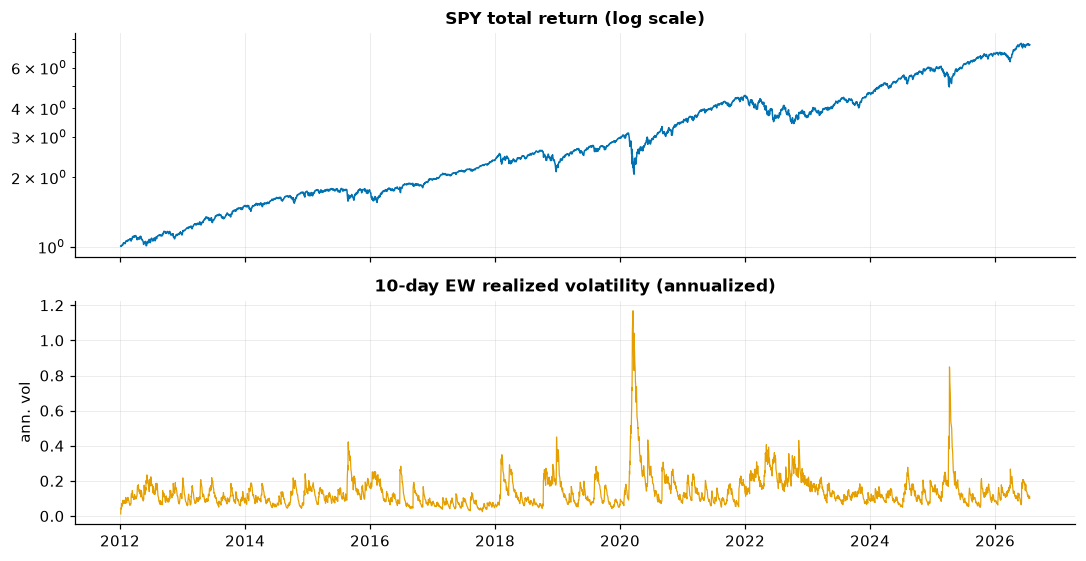

In [1]:
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import quantdata as qd
from quantroll import RollingRegimes, select_n_regimes, measures

warnings.filterwarnings("ignore", message="All-NaN")
qd.use_style()
PAL = qd.PALETTE

rets = qd.daily_returns(qd.load_prices("etf"))
spy = rets["SPY"].dropna()
vol10 = spy.ewm(span=10).std() * np.sqrt(252)
F = pd.DataFrame({"ret": spy, "vol10": vol10}).dropna()
price = (1 + spy).cumprod().reindex(F.index)

fig, axes = plt.subplots(2, 1, figsize=(10, 5.2), sharex=True)
axes[0].plot(price.index, price, color=PAL[0], lw=1.0)
axes[0].set_yscale("log"); axes[0].set_title("SPY total return (log scale)")
axes[1].plot(vol10.index, vol10, color=PAL[1], lw=0.8)
axes[1].set_title("10-day EW realized volatility (annualized)")
axes[1].set_ylabel("ann. vol")
plt.tight_layout()
print(f"feature matrix: {F.shape[0]:,} days x {list(F.columns)}")

## 1. Choosing features (this matters more than the model)

The model can only distinguish states whose fingerprints appear in its inputs — so the choice of features is where regime detection is really decided. A regime, as we defined it, is a *persistent distributional state*; the model should therefore be fed variables whose distributions actually differ between the states we care about. We use two:

- **the daily return itself** — it carries the *drift* difference: calm markets drift up, turbulent ones do not;
- **short-horizon realized volatility** — an exponentially-weighted standard deviation of roughly the last two trading weeks of returns, annualized. It carries the *scale* difference, which for equities is the dominant regime marker.

Two natural questions arise.

*Why not use prices?* Because prices are non-stationary: their level trends over the years, so "SPY at 400" tells you nothing about today's state. Returns and volatilities, by contrast, are comparable across the whole decade.

*Why include realized volatility when the HMM already models each state's variance?* Because a single day's return is a very weak witness of the state — a +0.1% day happens in every regime — so a model looking at one return at a time receives little evidence per day. Trailing volatility summarizes the last two weeks of behavior into each day's observation, sharpening the per-day evidence considerably.

The feature set extends without changing anything else in the notebook: credit spreads, term-structure slope, or market breadth would simply be extra columns.

## 2. How many regimes? Evidence first, then judgment

The number of states $K$ must be chosen, and the standard way to compare candidates is with *information criteria*. Both AIC and BIC start from the maximized log-likelihood — a measure of how well the fitted model explains the data — and subtract a penalty for the number of parameters, since a model with more knobs always fits better whether or not the extra structure is real. BIC penalizes harder than AIC. In both cases, **lower is better**. The table below fits maximum-likelihood HMMs with $K = 1, 2, 3, 4$ states and reports the criteria for each.

In [2]:
table = select_n_regimes(F.to_numpy(), candidates=(1, 2, 3, 4))
table.round(0)

,log_likelihood,n_params,aic,bic
n_regimes,,,,
1,14951.0,5,-29891.0,-29860.0
2,18203.0,13,-36381.0,-36300.0
3,19671.0,23,-39297.0,-39154.0
4,20547.0,35,-41025.0,-40808.0


### How to read this

BIC keeps improving as we add states — and this is the *typical* result on real financial returns, not an anomaly of our sample. The reason is worth understanding. Daily returns are *fat-tailed*: extreme days occur far more often than a normal distribution predicts. A mixture of several normal distributions approximates a fat-tailed distribution better with every component you add — so a purely statistical criterion will happily hand you five regimes, of which three are "slightly different shades of normal": states that improve the likelihood without meaning anything.

The selection table is therefore evidence, not a verdict. We proceed with **K = 2**, for three reasons: the decision we ultimately want to condition on is binary (risk-on sizing versus risk-off sizing); two states are nameable and auditable; and the marginal BIC gain from a third state buys statistical fit, not decision value. If your use case genuinely distinguishes "crash" from "choppy," run $K = 3$ and read the same summary tables.

## 3. Fit, and check the detected regimes against your memory

This section is the audit. Before anything is wired to a regime label, the label must survive a comparison with the history you actually lived through — a model that misses episodes you remember, or invents ones you don't, has no business sizing positions.

One parameter deserves comment before we fit: `window=1008`, i.e. four trading years — far longer than the six-month windows of notebook 01. The reason is fundamental: a regime that never appears inside the window cannot be learned from it. The window must be long enough to contain several visits to *each* state, and four years of daily equity data comfortably spans a few calm/turbulent cycles.

The estimator then proceeds day by day: it warm-starts each refit from the previous one, matches state identities against the slow-moving anchors (so "state 1" cannot silently become the calm state), filters the probabilities through the learned transition matrix, and changes its discrete call only when the filtered probability clears the hysteresis threshold.

Below, SPY's cumulative return with the model's turbulent periods shaded.

turbulent episodes lasting 15+ calendar days (21 of 38):
  2016-01-07 -> 2016-03-17   ( 70d)
  2016-06-24 -> 2016-07-15   ( 21d)
  2016-09-09 -> 2016-09-30   ( 21d)
  2018-02-02 -> 2018-05-11   ( 98d)
  2018-10-10 -> 2019-02-05   (118d)
  2019-05-13 -> 2019-06-13   ( 31d)
  2019-08-05 -> 2019-09-12   ( 38d)
  2019-10-02 -> 2019-10-22   ( 20d)
  2020-01-27 -> 2020-02-14   ( 18d)
  2020-02-24 -> 2020-07-21   (148d)
  2020-09-03 -> 2020-12-03   ( 91d)
  2021-01-27 -> 2021-02-11   ( 15d)
  2021-02-25 -> 2021-03-30   ( 33d)
  2021-11-26 -> 2021-12-29   ( 33d)
  2022-01-28 -> 2022-08-17   (201d)
  2022-08-22 -> 2023-01-12   (143d)
  2024-07-24 -> 2024-08-26   ( 33d)
  2024-12-18 -> 2025-01-13   ( 26d)
  2025-03-03 -> 2025-06-02   ( 91d)
  2026-03-27 -> 2026-04-15   ( 19d)
  2026-06-05 -> 2026-07-01   ( 26d)

identity relabels over the whole sample: 0


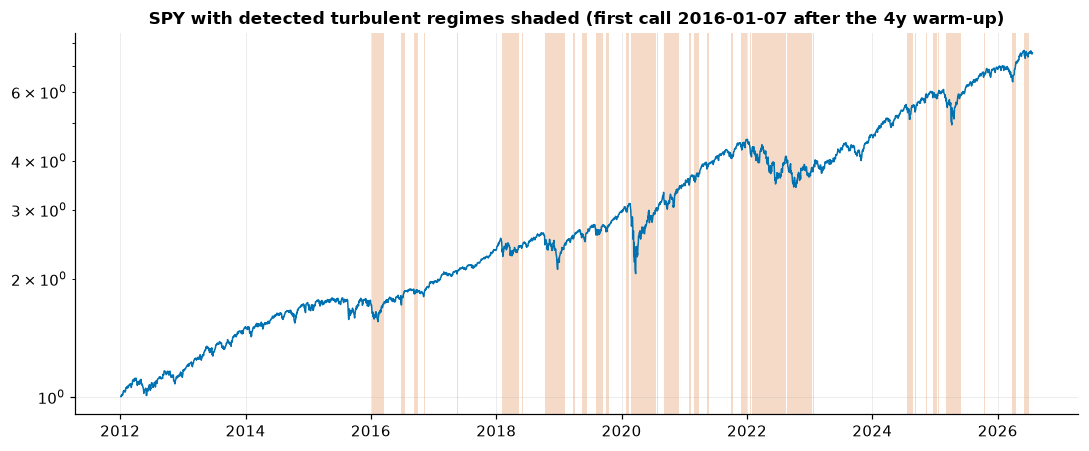

In [3]:
rr = RollingRegimes(n_regimes=2, window=1008).fit(F)
lab = rr.predict()          # pandas Series, -1 during the 4-year warm-up
probs = rr.predict_proba()
valid = lab >= 0

runs, cur, start, prev = [], None, None, None
for d, l in lab[valid].items():
    if l != cur:
        if cur == 1:
            runs.append((start, prev))
        cur, start = l, d
    prev = d
if cur == 1:
    runs.append((start, prev))

fig, ax = plt.subplots(figsize=(10, 4.2))
ax.plot(price.index, price, color=PAL[0], lw=1.0)
for s, e in runs:
    ax.axvspan(s, e, color=PAL[5], alpha=0.22, lw=0)
ax.set_yscale("log")
ax.set_title("SPY with detected turbulent regimes shaded "
             f"(first call {lab[valid].index[0].date()} after the 4y warm-up)")
plt.tight_layout()

long_runs = [(s, e, (e - s).days) for s, e in runs if (e - s).days >= 15]
print(f"turbulent episodes lasting 15+ calendar days ({len(long_runs)} of {len(runs)}):")
for s, e, days in long_runs:
    print(f"  {s.date()} -> {e.date()}   ({days:>3}d)")
print(f"\nidentity relabels over the whole sample: {rr.n_relabels_.sum()}")

### How to read this

Every shaded band is a period the model called *turbulent in real time* — the forward filter uses only data up to each day, so this is exactly what you would have seen on your screen each morning. Scan the printed episode list against what you remember:

- **Jan–Mar 2016** — China devaluation / oil collapse
- **Feb 2018** — "volmageddon", the XIV blow-up
- **Oct 2018 – Feb 2019** — the Q4-2018 rate-hike selloff
- **Feb–Jul 2020** — the COVID crash and its aftershocks
- **Jan 2022 – Jan 2023** — the inflation bear market, caught as two long spells
- **Jul–Aug 2024** — the yen-carry-trade unwind air pocket

The model was told nothing about any of these events. It saw two columns of numbers — returns and trailing volatility — and found the episodes on its own. Equally important is what it did *not* do: there are **zero identity relabels** (regime 1 means "turbulent" for the entire decade), and the long calm stretches are not chopped up by one-day scares.

## 4. The learned dynamics: persistence, spells, and per-regime behavior

The shaded chart showed *where* the model called turbulence. To trust it further, we look inside at *what it learned* — and at why the label is economically worth having at all.

Persistence in this model is **estimated, not imposed**: the transition probabilities are learned from the window, not set by hand. Two derived quantities make the learned dynamics tangible.

First, *expected spell length*. If a regime continues from one day to the next with probability $p$ (its diagonal entry in the transition matrix), then it exits with probability $1-p$ each day, and the expected number of days before it ends is $1/(1-p)$. A self-transition probability of 0.99 therefore implies spells of about 100 trading days on average.

Second, the *per-regime conditional statistics*: gather all days labeled calm and all days labeled turbulent, and compute each group's annualized return, volatility, Sharpe ratio, and best/worst days. This table is what makes the regime label worth having — it quantifies how differently the market behaves in the two states.

In [4]:
A = rr.transition_[-1]
spells = 1.0 / (1.0 - np.diag(A))
print("learned transition matrix (today):")
print(pd.DataFrame(A, index=["from calm", "from turb"],
                   columns=["to calm", "to turb"]).round(4).to_string())
print(f"\nimplied average spells: calm {spells[0]:.0f} days, turbulent {spells[1]:.0f} days")
print(f"stationary shares:      calm {rr.result_.weights[-1][0]:.0%}, "
      f"turbulent {rr.result_.weights[-1][1]:.0%}")

stats = []
for k, name in [(0, "calm"), (1, "turbulent")]:
    r = spy.reindex(F.index)[lab == k]
    stats.append({"regime": name, "days": len(r),
                  "ann_return": r.mean() * 252, "ann_vol": r.std() * np.sqrt(252),
                  "sharpe": r.mean() / r.std() * np.sqrt(252),
                  "worst_day": r.min(), "best_day": r.max()})
pd.DataFrame(stats).set_index("regime").round(3)

learned transition matrix (today):
           to calm  to turb
from calm   0.9862   0.0138
from turb   0.0363   0.9637

implied average spells: calm 72 days, turbulent 28 days
stationary shares:      calm 72%, turbulent 28%


,days,ann_return,ann_vol,sharpe,worst_day,best_day
regime,,,,,,
calm,1646,0.208,0.097,2.152,-0.020,0.021
turbulent,1003,0.076,0.262,0.291,-0.109,0.105


### How to read this

The learned self-transition probabilities (≈ 0.98–0.99) imply average spells measured in **months, not days** — the model discovered equity volatility clustering on its own, from the data, with no smoothing constant imposed by us.

The conditional table is the payoff. On this sample, calm days compound at roughly **+20% annualized with ~10% volatility (Sharpe ≈ 2)**, while turbulent days deliver a small fraction of that return at **~26% volatility (Sharpe ≈ 0.3)** — read the exact figures in the printed table above. Notice also that both the best *and* the worst single days of the decade fall inside the turbulent regime. That is not a flaw in the labeling — violent rallies inside bear markets are a classic feature of turbulence — and it is exactly the fat-tailed, whipsawing environment the label is meant to isolate.

Put plainly: nearly all of the equity risk premium of the past decade was earned in the calm state.

## 5. Why the filter and hysteresis earn their keep

A conditioning variable must be more than accurate on average; it must be *quiet*. Everything wired downstream pays for each flip of the call — in transactions, in false alarms, in eroded confidence — so the filtering machinery has to justify its complexity here, in flips avoided.

For comparison, there is a simpler way to produce labels: each day, ask "which state best explains *today's observation alone*?" and take the more likely one. The cell below counts how often that naive per-day call changes state, and compares it with the filtered, hysteresis-gated call the model actually makes.

In [5]:
raw = np.argmax(np.nan_to_num(rr.result_.raw_probs), axis=1)[valid.to_numpy()]
naive_changes = int((np.diff(raw) != 0).sum())
print(f"naive per-day argmax:      {naive_changes} regime changes")
print(f"filtered + hysteresis:     {int(rr.switched_.sum())} regime changes "
      f"({naive_changes / max(int(rr.switched_.sum()),1):.1f}x fewer)")

naive per-day argmax:      269 regime changes
filtered + hysteresis:     75 regime changes (3.6x fewer)


The difference is large, and it matters. If anything downstream trades on the regime call, every extra flip is a transaction — and nearly all of the naive flips are false alarms: single noisy days inside an unchanged regime. The forward filter prevents them by *accumulating* evidence. One bad day inside a calm market raises the turbulence probability; the discrete call flips only if the evidence keeps piling up over the following days. That patience is precisely what the learned persistence buys.

## 6. What is it worth? A deliberately simple illustration

To show that the regime probability carries usable information, we run the simplest conceivable regime-conditioned rule: scale SPY exposure by the filtered *calm* probability — full exposure when confidently calm, shrinking toward a 35% floor as the turbulence probability rises. We use *yesterday's* probability to set today's exposure, so the rule contains no look-ahead.

Be clear about what this is: an illustration of information content, **not** an investable strategy. Transaction costs, capacity, and robustness checks are out of scope, and the per-regime statistics shown earlier are computed on the full sample.

,ann_return,ann_vol,sharpe,max_drawdown,calmar
,,,,,
buy & hold SPY,0.153,0.178,0.888,-0.337,0.453
regime-scaled SPY,0.104,0.103,1.020,-0.159,0.656


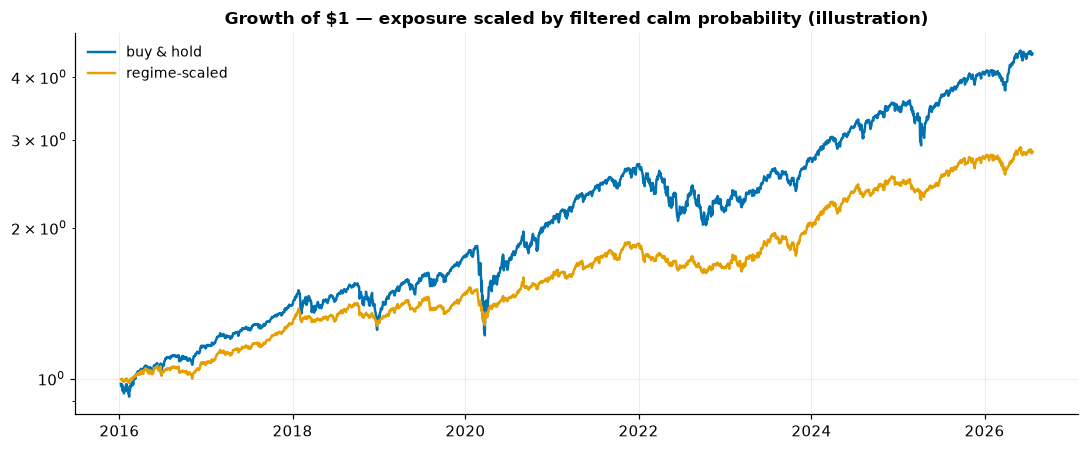

In [6]:
p_calm = probs["regime_0"].shift(1).reindex(F.index)
exposure = (0.35 + 0.65 * p_calm).clip(0, 1)          # 35% floor in full turbulence
r_bh = spy.reindex(F.index)[valid]
r_rs = (spy.reindex(F.index) * exposure)[valid]

rows = []
for name, r in [("buy & hold SPY", r_bh), ("regime-scaled SPY", r_rs)]:
    rows.append({"": name,
                 "ann_return": float(measures.cagr(r.to_numpy())),
                 "ann_vol": float(measures.ann_vol(r.to_numpy())),
                 "sharpe": float(measures.sharpe(r.to_numpy())),
                 "max_drawdown": float(measures.max_drawdown(r.to_numpy())),
                 "calmar": float(measures.calmar(r.to_numpy()))})
display(pd.DataFrame(rows).set_index("").round(3))

fig, ax = plt.subplots()
ax.plot((1 + r_bh).cumprod(), label="buy & hold", color=PAL[0])
ax.plot((1 + r_rs).cumprod(), label="regime-scaled", color=PAL[1])
ax.set_yscale("log"); ax.legend()
ax.set_title("Growth of $1 — exposure scaled by filtered calm probability (illustration)")
plt.tight_layout()

### How to read this

Compare the two rows *by risk*, not by raw return. The regime-scaled version holds less than 100% exposure much of the time, so its headline return can lag buy-and-hold — that is expected, and not the point. The informative columns are **volatility, Sharpe, maximum drawdown, and Calmar** (annualized return divided by maximum drawdown — return per unit of worst-case pain). Regime awareness helps on exactly these, because the rule lightens exposure during the fat-tailed stretches identified in section 3. The equity-curve chart makes the mechanism visible: the scaled curve flattens through the shaded crisis periods instead of riding them down.

## 7. Production shape: the 8:59 a.m. loop

In production you never refit history. Each morning you `update()` with yesterday's feature row and read off the fresh filtered probability. The cell verifies that this streaming path is *identical* to the batch fit — same arithmetic, a fraction of a millisecond per day.

In [7]:
rr_live = RollingRegimes(n_regimes=2, window=1008).fit(F.iloc[:-40])
rr_live.update(F.iloc[-40:])
same = np.array_equal(rr_live.labels_, rr.labels_)
print(f"fit(history) + 40 daily updates == fit(everything): {same}")
p = rr_live.predict_proba().iloc[-1]
print(f"this morning's filtered probabilities:  calm {p['regime_0']:.1%}, "
      f"turbulent {p['regime_1']:.1%}  ->  call: "
      f"{['calm','turbulent'][int(rr_live.predict().iloc[-1])]}")

fit(history) + 40 daily updates == fit(everything): True
this morning's filtered probabilities:  calm 99.9%, turbulent 0.1%  ->  call: calm


## What you now have, and what it's worth

| Output | Use it for |
|---|---|
| Daily filtered regime probability | condition sizing, stops, hedges, signal on/off on it |
| Shaded episode history | audit the model against events you remember before trusting it |
| Learned transition matrix & spells | honest persistence estimates (no hand-tuned smoothing constant) |
| Per-regime conditional stats | quantify *why* the regime matters for your book |
| Hysteresis-gated calls | 3–4× fewer false alarms than per-day classification |
| `update()` streaming | a one-line morning job, provably identical to batch |

Notice the proportions of this notebook: producing the probability took one section; earning the right to trust it took five. For anything you intend to wire real decisions to, that ratio is about right — and it is only achievable because the label's identity is stable enough to be audited at all.

**Next:** notebook `03` moves from the time dimension to the cross-section — stable peer groups of individual stocks.